Code: **Power spectrum calculation for three-field model**  
Date: March 2026  
Written by: Mehdi Nasrolahzadeh  

In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

In [2]:
# constants:

V0 = 36.5e-10
Mp = 1
mchi = np.sqrt(V0 / 400)
mpsi = np.sqrt(V0 / 140000) #np.sqrt(V0 / 65000) 
phi0 = np.sqrt(6) * Mp
b0 = 7.7#7.68 
y0 = 6.8 
p0 = 6.85  
mp = 2.435515 * 1e18
mpc = (6.394970897 * 1e-39) / mp   # Mpc^{-1} =  2.63 * 1e-57 Mp (arXiv: 2110.12251)
k0 = 0.05 * mpc

In [3]:
def power(a,b):     # a ^ b
    s = 1
    for i in range(b):
        s *= a
    return s

In [4]:
# potential V(phi,chi,psi):

def V(phi,chi,psi):
    return V0 * power(phi,2) / (power(phi0,2) + power(phi,2)) + 0.5 * power(mchi,2) * power(chi,2) + 0.5 * power(mpsi,2) * power(psi,2) +  0.5 * 8e-13 * phi ** 2 * psi ** 2

# derivates of the potential:


def V_phi(phi,chi,psi):
   h = 1e-5
   return (V(phi + h,chi,psi) - V(phi - h,chi,psi)) / (2 * h)

def V_chi(phi,chi,psi):
   h = 1e-5
   return (V(phi,chi + h,psi) - V(phi,chi - h,psi)) / (2 * h)

def V_psi(phi,chi,psi):
   h = 1e-5
   return (V(phi,chi,psi + h) - V(phi,chi,psi - h)) / (2 * h)

def V_phiphi(phi,chi,psi):
   h = 1e-5
   return (V_phi(phi + h , chi,psi) - V_phi(phi - h , chi,psi)) / (2 * h)

def V_chichi(phi,chi,psi):
   h = 1e-5
   return (V_chi(phi,chi + h,psi) - V_chi(phi,chi - h,psi)) / (2 * h)

def V_psipsi(phi,chi,psi):
   h = 1e-5
   return (V_psi(phi,chi,psi + h) - V_psi(phi,chi,psi - h)) / (2 * h)

def V_phichi(phi,chi,psi):
   h = 1e-5
   return (V_phi(phi,chi + h,psi) - V_phi(phi,chi - h,psi)) / (2 * h)

def V_phipsi(phi,chi,psi):
   h = 1e-5
   return (V_phi(phi,chi,psi + h) - V_phi(phi,chi,psi - h)) / (2 * h)

def V_chipsi(phi,chi,psi):
   h = 1e-5
   return (V_chi(phi,chi,psi + h) - V_chi(phi,chi,psi - h)) / (2 * h)

In [5]:
# noncanonical coefficients:

def b(phi):
    return b0 * phi
def y(phi):
    return y0 * phi
def p(chi):
    return p0 * chi

# derivatives:

def b_phi(phi):
    h = 1e-5
    return (b(phi + h) - b(phi - h)) / (2 * h)
def y_phi(phi):
    h = 1e-5
    return (y(phi + h) - y(phi - h)) / (2 * h)
def p_chi(chi):
    h = 1e-5
    return (p(chi + h) - p(chi - h)) / (2 * h)

# second derivatives for perturbations:

def b_phiphi(phi):
    h = 1e-5
    return (b_phi(phi + h) - b_phi(phi - h)) / (2 * h)
def y_phiphi(phi):
    h = 1e-5
    return (y_phi(phi + h) - y_phi(phi - h)) / (2 * h)
def p_chichi(chi):
    h = 1e-5
    return (p_chi(chi + h) - p_chi(chi - h)) / (2 * h)

In [6]:
def G_ab(phi,chi):     # field-space metric
    return np.array([[1,0,0],[0, np.exp(2 * b(phi)) ,0],[0,0, np.exp(2 * y(phi) + 2 * p(chi))]])

<center>
  <span style="color: #ff5722; font-weight: bold; font-size: 1.2em;">
    Background evolution
  </span>
</center>

In [7]:
def H(phi,chi,psi,dphi_dN,dchi_dN,dpsi_dN):
    G = G_ab(phi,chi)
    value = np.sqrt((2 * V(phi,chi,psi)) / (6 * power(Mp,2) - G[0][0] * power(dphi_dN,2) - G[1][1] * power(dchi_dN ,2) - G[2][2] * power(dpsi_dN ,2)))
    return value

def dH_dN(phi,chi,psi,dphi_dN,dchi_dN,dpsi_dN):
    G = G_ab(phi,chi)
    Hub = H(phi,chi,psi,dphi_dN,dchi_dN,dpsi_dN)
    value = - 0.5 * (1 / power(Mp,2)) * Hub * (G[0][0] * power(dphi_dN ,2) + G[1][1] * power(dchi_dN,2) + G[2][2] * power(dpsi_dN,2))
    return value

def numeps(phi,chi,psi,dphi_dN,dchi_dN,dpsi_dN):
    Hub = H(phi,chi,psi,dphi_dN,dchi_dN,dpsi_dN)
    dH = dH_dN(phi,chi,psi,dphi_dN,dchi_dN,dpsi_dN)
    return - dH / Hub

In [8]:
# Background equations of motion:

def background(N,y):
    phi, dphi_dN, chi, dchi_dN, psi, dpsi_dN = y
    H_val = H(phi,chi,psi,dphi_dN,dchi_dN,dpsi_dN)
    eps = numeps(phi,chi,psi,dphi_dN,dchi_dN,dpsi_dN)
    G = G_ab(phi,chi)
    d2phi_dN2 = -(3 - eps) * dphi_dN + b_phi(phi) * G[1][1] * power(dchi_dN,2) + y_phi(phi) * G[2][2] * power(dpsi_dN,2) - V_phi(phi,chi,psi) / power(H_val,2)
    d2chi_dN2 = -(3 + 2 * b_phi(phi) * dphi_dN - eps) * dchi_dN + p_chi(chi) * (G[2][2] / G[1][1]) * power(dpsi_dN,2) - (1 / G[1][1]) * V_chi(phi,chi,psi) / power(H_val,2)
    d2psi_dN2 = -(3 + 2 * b_phi(phi) * dphi_dN + 2 * p_chi(chi) * dchi_dN - eps) * dpsi_dN - (1 / G[2][2]) * V_psi(phi,chi,psi) / power(H_val,2)
    return np.array([dphi_dN, d2phi_dN2, dchi_dN, d2chi_dN2, dpsi_dN, d2psi_dN2])

In [9]:
# Initial condition + Integration:

phi_i = 7
chi_i = 7.31
psi_i = 7.31
phi_dot_i = 0 #- V_phi(phi_i,chi_i,psi_i) / V(phi_i,chi_i,psi_i)
chi_dot_i = 0 #- V_chi(phi_i,chi_i,psi_i) / V(phi_i,chi_i,psi_i)
psi_dot_i = 0 #- V_psi(phi_i,chi_i,psi_i) / V(phi_i,chi_i,psi_i)
Inc = np.array([phi_i, phi_dot_i, chi_i, chi_dot_i, psi_i, psi_dot_i])
 
sample_size = 10000 # to pass the stiffness
NEnd = 70.64 # estimated endpoint for inflation

NE = np.linspace(0 , NEnd, sample_size)
sol_background = solve_ivp(background, [0 , NEnd], Inc,t_eval=NE,
                          method='RK45', rtol=1e-6, atol=1e-8)
N_vals = sol_background.t
phi_vals = sol_background.y[0]
dphidN = sol_background.y[1]
chi_vals = sol_background.y[2]
dchidN = sol_background.y[3]
psi_vals = sol_background.y[4]
dpsidN = sol_background.y[5]

Hubble_vals = [H(phi_vals[i],chi_vals[i],psi_vals[i],dphidN[i],dchidN[i],dpsidN[i]) for i in range(len(N_vals))]
epsilon = np.array([-(1 / H(phi_vals[i],chi_vals[i],psi_vals[i],dphidN[i],dchidN[i],dpsidN[i])) * dH_dN(phi_vals[i],chi_vals[i],psi_vals[i],dphidN[i],dchidN[i],dpsidN[i]) for i in range(len(N_vals))])
Eta = np.gradient(epsilon,N_vals) / epsilon

C:\Users\Mehdi\AppData\Local\Temp\ipykernel_19500\1400924291.py:27: RuntimeWarning: divide by zero encountered in divide
  Eta = np.gradient(epsilon,N_vals) / epsilon


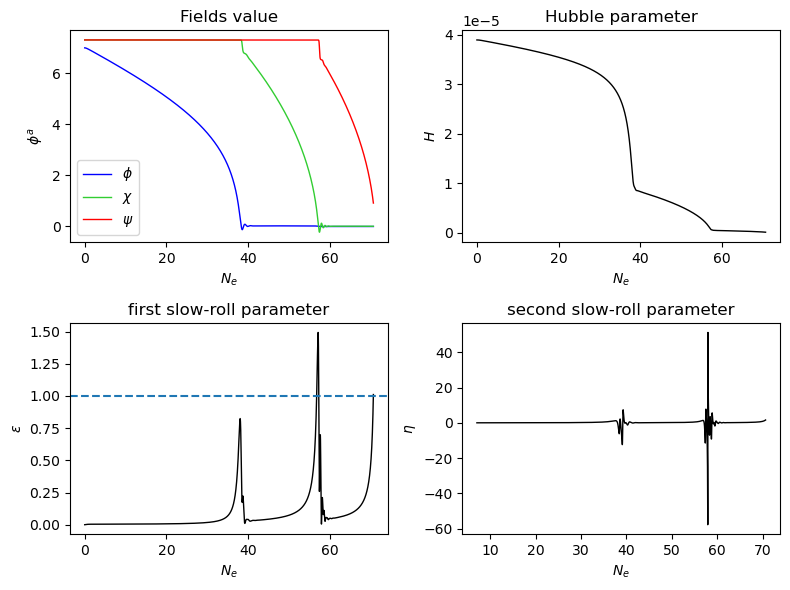

In [10]:
fig = plt.figure(figsize=(8, 6))

ax1 = fig.add_subplot(2, 2, 1) 
ax1.plot(N_vals, phi_vals, label=r'$\phi$', color='blue',linewidth=1)
ax1.plot(N_vals, chi_vals, label=r'$\chi$', color='limegreen',linewidth=1)
ax1.plot(N_vals, psi_vals, label=r'$\psi$', color='r',linewidth=1)
ax1.set_xlabel(r"$N_e$")
ax1.set_ylabel(r'$\phi^a$')
plt.legend()
ax1.set_title('Fields value')

ax2 = fig.add_subplot(2, 2, 2)
ax2.plot(N_vals,Hubble_vals,color='black',linewidth=1)
ax2.set_xlabel(r"$N_e$")
ax2.set_ylabel(r"$H$")
ax2.set_title('Hubble parameter')

ax3 = fig.add_subplot(2, 2, 3)
ax3.plot(N_vals,epsilon, color='black',linewidth=1)
ax3.axhline(1,linestyle='--')
ax3.set_xlabel(r"$N_e$")
ax3.set_ylabel(r"$\epsilon$")
ax3.set_title('first slow-roll parameter')

ax4 = fig.add_subplot(2, 2, 4)
ax4.plot(N_vals[1000:],Eta[1000:],color='black',linewidth=1)
ax4.set_xlabel(r"$N_e$")
ax4.set_ylabel(r"$\eta$")
ax4.set_title('second slow-roll parameter')

plt.tight_layout()
#plt.savefig('3fields_background.pdf',format = 'pdf' , dpi = 700)
plt.show()

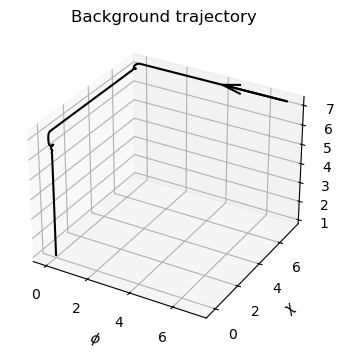

In [11]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(4,4))
ax = fig.add_subplot(111, projection='3d')
ax.plot(phi_vals, chi_vals, psi_vals,color='black')
ax.quiver(phi_vals[0], chi_vals[0], psi_vals[0],phi_vals[1]-phi_vals[0], chi_vals[1]-chi_vals[0], psi_vals[1]-psi_vals[0],
    length=3.0, normalize=True, color='black', arrow_length_ratio=.3)
ax.set_xlabel(r'$\phi$')
ax.set_ylabel(r'$\chi$')
ax.set_zlabel(r'$\psi$')
ax.set_title('Background trajectory')
plt.show()

In [12]:
cands = np.where(np.abs(epsilon-1) < 1e-2)[0]
end_inf = cands[np.argmin(np.abs(N_vals[cands]- NEnd))]
N_vals[end_inf]

np.float64(70.63293529352936)

In [13]:
#end_inf = np.argmin(np.abs(1 - epsilon))
N_end = N_vals[end_inf]
N_pivot = N_end - 50 
pivot_idx = np.argmin(np.abs(N_pivot - N_vals))
a0 = (k0 / Hubble_vals[pivot_idx]) * np.exp(-N_vals[pivot_idx])    # normalize a(N) so that k∗ = 0.05 crosses the Hubble radius N∗ = 50 e-folds before the end of inflation.
a_vals = a0 * np.exp(N_vals)
K = a_vals * Hubble_vals  # Comoving Hubble scale

In [15]:
print('N_end =',N_vals[end_inf])
print('ϵ =', epsilon[end_inf])

N_end = 70.63293529352936
ϵ = 0.9993619315668492


<center>
  <span style="color: #ff5722; font-weight: bold; font-size: 1.2em;">
    Turning parameters (TNB method) 
  </span>
</center>

In [16]:
def sigma_dot(Ne):
    idx = np.argmin(np.abs(Ne - N_vals))
    phi = phi_vals[idx]
    dphi = dphidN[idx]
    chi = chi_vals[idx]
    dchi = dchidN[idx]
    psi = psi_vals[idx]
    dpsi = dpsidN[idx]
    Hub = H(phi,chi,psi,dphi,dchi,dpsi)
    G = G_ab(phi,chi)
    val = power(Hub,2) * (dphi ** 2 + G[1][1] * dchi ** 2 + G[2][2] * dpsi ** 2)
    return np.sqrt(val) 

In [17]:
sigma_vals = [sigma_dot(ne) for ne in N_vals]

In [18]:
# tangent vector to the background trajectory:

T1 , T2 , T3 = [] , [] , []
for i in range(len(N_vals)):
    T1.append(Hubble_vals[i] * dphidN[i] / sigma_vals[i])
    T2.append(Hubble_vals[i] * dchidN[i] / sigma_vals[i])
    T3.append(Hubble_vals[i] * dpsidN[i] / sigma_vals[i])
T1 = np.array(T1)
T2 = np.array(T2)
T3 = np.array(T3)

C:\Users\Mehdi\AppData\Local\Temp\ipykernel_19500\111139596.py:5: RuntimeWarning: invalid value encountered in scalar divide
  T1.append(Hubble_vals[i] * dphidN[i] / sigma_vals[i])
C:\Users\Mehdi\AppData\Local\Temp\ipykernel_19500\111139596.py:6: RuntimeWarning: invalid value encountered in scalar divide
  T2.append(Hubble_vals[i] * dchidN[i] / sigma_vals[i])
C:\Users\Mehdi\AppData\Local\Temp\ipykernel_19500\111139596.py:7: RuntimeWarning: invalid value encountered in scalar divide
  T3.append(Hubble_vals[i] * dpsidN[i] / sigma_vals[i])


In [19]:
def turning(Ne):
    idx = np.argmin(np.abs(Ne - N_vals))
    phi = phi_vals[idx]
    dphi = dphidN[idx]
    chi = chi_vals[idx]
    dchi = dchidN[idx]
    psi = psi_vals[idx]
    dpsi = dpsidN[idx]
    Hub = H(phi,chi,psi,dphi,dchi,dpsi)
    G = G_ab(phi,chi)
    ddotphi = -3 * Hub ** 2 * dphi + b_phi(phi) * G[1][1] * Hub ** 2 * dchi ** 2 + y_phi(phi) * G[2][2] * Hub ** 2 * dpsi ** 2 - V_phi(phi,chi,psi)
    ddotchi = - (3 + 2 * b_phi(phi) * dphi) * power(Hub,2) * dchi + p_chi(chi) * (G[2][2] / G[1][1]) * power(Hub * dpsi,2) - V_chi(phi,chi,psi) / G[1][1]
    ddotpsi = - (3 + 2 * y_phi(phi) * dphi + 2 * p_chi(chi) * dchi) * power(Hub,2) * dpsi - V_psi(phi,chi,psi) / G[2][2]
    ddotsigma = (Hub * ddotphi * dphi + G[1][1] * Hub * ddotchi * dchi + G[2][2] * Hub * ddotpsi * dpsi + b_phi(phi) * G[1][1] * power(Hub,3) * power(dchi,2) * dphi + y_phi(phi) * G[2][2] * power(Hub,3) * power(dpsi,2) * dphi + p_chi(chi) * G[2][2] * power(Hub,3) * power(dpsi,2) * dchi) / sigma_dot(Ne)
    Dtphi = - 3 * power(Hub,2) * dphi - V_phi(phi,chi,psi) / G[0][0]
    Dtchi = - 3 * power(Hub,2) * dchi - V_chi(phi,chi,psi) / G[1][1]
    Dtpsi = - 3 * power(Hub,2) * dpsi - V_psi(phi,chi,psi) / G[2][2]
    DtT1 = Dtphi / sigma_dot(Ne) - Hub * dphi * ddotsigma / power(sigma_dot(Ne),2)
    DtT2 = Dtchi / sigma_dot(Ne) - Hub * dchi * ddotsigma / power(sigma_dot(Ne),2)
    DtT3 = Dtpsi / sigma_dot(Ne) - Hub * dpsi * ddotsigma / power(sigma_dot(Ne),2)
    val = power(DtT1,2) + G[1][1] * power(DtT2,2) + G[2][2] * power(DtT3,2)
    return np.sqrt(val)        

In [20]:
OMEGA = []
for i in range(len(N_vals)):
    OMEGA.append(turning(N_vals[i]))

OMEGA = np.array(OMEGA)

C:\Users\Mehdi\AppData\Local\Temp\ipykernel_19500\4089862413.py:14: RuntimeWarning: invalid value encountered in scalar divide
  ddotsigma = (Hub * ddotphi * dphi + G[1][1] * Hub * ddotchi * dchi + G[2][2] * Hub * ddotpsi * dpsi + b_phi(phi) * G[1][1] * power(Hub,3) * power(dchi,2) * dphi + y_phi(phi) * G[2][2] * power(Hub,3) * power(dpsi,2) * dphi + p_chi(chi) * G[2][2] * power(Hub,3) * power(dpsi,2) * dchi) / sigma_dot(Ne)
C:\Users\Mehdi\AppData\Local\Temp\ipykernel_19500\4089862413.py:18: RuntimeWarning: divide by zero encountered in scalar divide
  DtT1 = Dtphi / sigma_dot(Ne) - Hub * dphi * ddotsigma / power(sigma_dot(Ne),2)
C:\Users\Mehdi\AppData\Local\Temp\ipykernel_19500\4089862413.py:19: RuntimeWarning: divide by zero encountered in scalar divide
  DtT2 = Dtchi / sigma_dot(Ne) - Hub * dchi * ddotsigma / power(sigma_dot(Ne),2)
C:\Users\Mehdi\AppData\Local\Temp\ipykernel_19500\4089862413.py:20: RuntimeWarning: divide by zero encountered in scalar divide
  DtT3 = Dtpsi / sigma_do

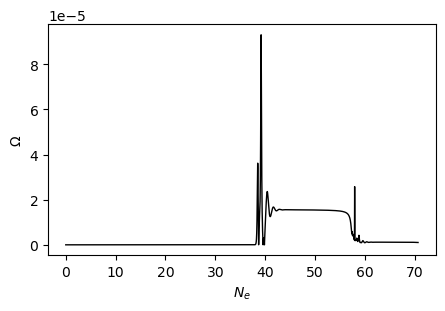

In [21]:
plt.figure(figsize=(5,3))
plt.plot(N_vals,OMEGA,color='black',linewidth=1)
plt.xlabel(r"$N_e$")
plt.ylabel(r"$\Omega$")
#plt.axhline(6e-6,linestyle='--')
plt.show()

In [22]:
def Normal(Ne):
    idx = np.argmin(np.abs(Ne - N_vals))
    phi = phi_vals[idx]
    dphi = dphidN[idx]
    chi = chi_vals[idx]
    dchi = dchidN[idx]
    psi = psi_vals[idx]
    dpsi = dpsidN[idx]
    Hub = H(phi,chi,psi,dphi,dchi,dpsi)
    G = G_ab(phi,chi)
    ddotphi = -3 * Hub ** 2 * dphi + b_phi(phi) * G[1][1] * Hub ** 2 * dchi ** 2 + y_phi(phi) * G[2][2] * Hub ** 2 * dpsi ** 2 - V_phi(phi,chi,psi)
    ddotchi = - (3 + 2 * b_phi(phi) * dphi) * power(Hub,2) * dchi + p_chi(chi) * (G[2][2] / G[1][1]) * power(Hub * dpsi,2) - V_chi(phi,chi,psi) / G[1][1]
    ddotpsi = - (3 + 2 * y_phi(phi) * dphi + 2 * p_chi(chi) * dchi) * power(Hub,2) * dpsi - V_psi(phi,chi,psi) / G[2][2]
    ddotsigma = (Hub * ddotphi * dphi + G[1][1] * Hub * ddotchi * dchi + G[2][2] * Hub * ddotpsi * dpsi + b_phi(phi) * G[1][1] * power(Hub,3) * power(dchi,2) * dphi + y_phi(phi) * G[2][2] * power(Hub,3) * power(dpsi,2) * dphi + p_chi(chi) * G[2][2] * power(Hub,3) * power(dpsi,2) * dchi) / sigma_dot(Ne)
    Dtphi = - 3 * power(Hub,2) * dphi - V_phi(phi,chi,psi) / G[0][0]
    Dtchi = - 3 * power(Hub,2) * dchi - V_chi(phi,chi,psi) / G[1][1]
    Dtpsi = - 3 * power(Hub,2) * dpsi - V_psi(phi,chi,psi) / G[2][2]
    DtT1 = Dtphi / sigma_dot(Ne) - Hub * dphi * ddotsigma / power(sigma_dot(Ne),2)
    DtT2 = Dtchi / sigma_dot(Ne) - Hub * dchi * ddotsigma / power(sigma_dot(Ne),2)
    DtT3 = Dtpsi / sigma_dot(Ne) - Hub * dpsi * ddotsigma / power(sigma_dot(Ne),2)
    val = power(DtT1,2) + G[1][1] * power(DtT2,2) + G[2][2] * power(DtT3,2)
    Omega = np.sqrt(val)
    N1 = DtT1 / Omega
    N2 = DtT2 / Omega
    N3 = DtT3 / Omega
    return N1 , N2 , N3

In [23]:
N1 , N2 , N3 = [] , [] , []
for i in range(len(N_vals)):
    N1.append(Normal(N_vals[i])[0])
    N2.append(Normal(N_vals[i])[1])
    N3.append(Normal(N_vals[i])[2])
N1 = np.array(N1)
N2 = np.array(N2)
N3 = np.array(N3)

C:\Users\Mehdi\AppData\Local\Temp\ipykernel_19500\314829298.py:14: RuntimeWarning: invalid value encountered in scalar divide
  ddotsigma = (Hub * ddotphi * dphi + G[1][1] * Hub * ddotchi * dchi + G[2][2] * Hub * ddotpsi * dpsi + b_phi(phi) * G[1][1] * power(Hub,3) * power(dchi,2) * dphi + y_phi(phi) * G[2][2] * power(Hub,3) * power(dpsi,2) * dphi + p_chi(chi) * G[2][2] * power(Hub,3) * power(dpsi,2) * dchi) / sigma_dot(Ne)
C:\Users\Mehdi\AppData\Local\Temp\ipykernel_19500\314829298.py:18: RuntimeWarning: divide by zero encountered in scalar divide
  DtT1 = Dtphi / sigma_dot(Ne) - Hub * dphi * ddotsigma / power(sigma_dot(Ne),2)
C:\Users\Mehdi\AppData\Local\Temp\ipykernel_19500\314829298.py:19: RuntimeWarning: divide by zero encountered in scalar divide
  DtT2 = Dtchi / sigma_dot(Ne) - Hub * dchi * ddotsigma / power(sigma_dot(Ne),2)
C:\Users\Mehdi\AppData\Local\Temp\ipykernel_19500\314829298.py:20: RuntimeWarning: divide by zero encountered in scalar divide
  DtT3 = Dtpsi / sigma_dot(Ne

In [24]:
def Binormal(Ne):
    idx = np.argmin(np.abs(Ne - N_vals))
    phi = phi_vals[idx]
    psi = psi_vals[idx]
    chi = chi_vals[idx]
    G = G_ab(phi,chi)
    detG = G[1][1] * G[2][2]
    t1 = G[0][0] * T1[idx]
    t2 = G[1][1] * T2[idx]
    t3 = G[2][2] * T3[idx]
    n1 = G[0][0] * N1[idx]
    n2 = G[1][1] * N2[idx]
    n3 = G[2][2] * N3[idx]
    B1 = (t2 * n3 - t3 * n2) / np.sqrt(detG)
    B2 = (t3 * n1 - t1 * n3) / np.sqrt(detG)
    B3 = (t1 * n2 - t2 * n1) / np.sqrt(detG)
    return B1 , B2 , B3    

In [25]:
B1 , B2 , B3 = [] , [] , []
for i in range(len(N_vals)):
    B1.append(Binormal(N_vals[i])[0])
    B2.append(Binormal(N_vals[i])[1])
    B3.append(Binormal(N_vals[i])[2])
B1 = np.array(B1)
B2 = np.array(B2)
B3 = np.array(B3)

In [26]:
def torsion(Ne): 
    idx = np.argmin(np.abs(Ne - N_vals))
    phi = phi_vals[idx]
    dphi = dphidN[idx]
    psi = psi_vals[idx]
    dpsi = dpsidN[idx]
    chi = chi_vals[idx]
    dchi = dchidN[idx]
    Hub = H(phi,chi,psi,dphi,dchi,dpsi)
    G = G_ab(phi,chi)
    Γ122 = -b_phi(phi) * G[1][1] 
    Γ133 = -y_phi(phi) * G[2][2]
    Γ212 = b_phi(phi)
    Γ221 = Γ212
    Γ233 = -p_chi(chi) * G[2][2] / G[1][1]
    Γ313 = y_phi(phi)
    Γ331 = Γ313
    Γ323 = p_chi(chi)
    Γ332 = Γ323
    B1dot = Hub * np.gradient(B1,N_vals)[idx]
    B2dot = Hub * np.gradient(B2,N_vals)[idx]
    B3dot = Hub * np.gradient(B3,N_vals)[idx]
    DtB1 = B1dot + Γ122 * B2[idx] * Hub * dchi + Γ133 * B3[idx] * Hub * dpsi
    DtB2 = B2dot + Γ212 * B2[idx] * Hub * dphi + Γ221 * B1[idx] * Hub * dchi + Γ233 * B3[idx] * Hub * dpsi
    DtB3 = B3dot + Γ313 * B3[idx] * Hub * dphi + Γ331 * B1[idx] * Hub * dpsi + Γ323 * B3[idx] * Hub * dchi + Γ332 * B2[idx] * Hub * dpsi
    n1 = G[0][0] * N1[idx]
    n2 = G[1][1] * N2[idx]
    n3 = G[2][2] * N3[idx]
    torz = - n1 * DtB1 - n2 * DtB2 - n3 * DtB3
    return torz

In [27]:
TORSION = []
for i in range(len(N_vals)):
    TORSION.append(torsion(N_vals[i]))

TORSION = np.array(TORSION)

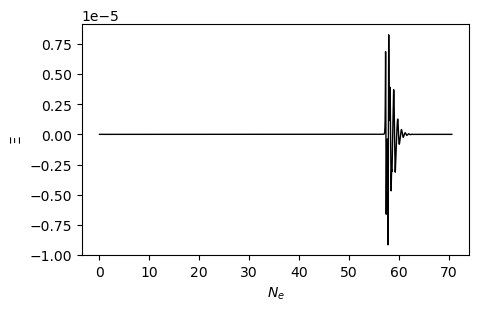

In [28]:
plt.figure(figsize=(5,3))
plt.plot(N_vals,TORSION,color='black',linewidth=1)
plt.xlabel(r"$N_e$")
plt.ylabel(r"$\Xi$")
#plt.xlim(20,NEnd)
plt.show()

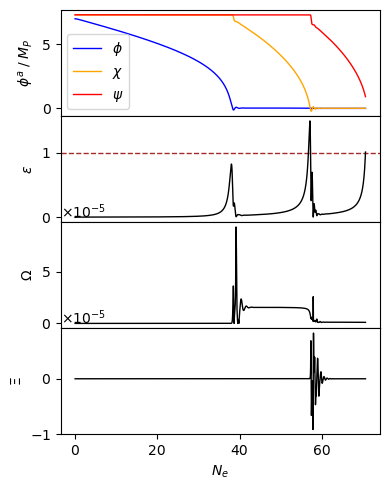

In [30]:
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(4,5), sharex=True, gridspec_kw={'hspace': 0})

ax1, ax2, ax3, ax4 = axes
ax1.plot(N_vals, phi_vals, label=r'$\phi$', color='blue',linewidth=1)
ax1.plot(N_vals, chi_vals, label=r'$\chi$', color='orange',linewidth=1)
ax1.plot(N_vals, psi_vals, label=r'$\psi$', color='r',linewidth=1)
ax1.set_ylabel(r'$\phi^a\;/\;M_P$')
ax1.legend()

ax2.axhline(1,linestyle='--',linewidth=1,color='brown')
ax2.plot(N_vals,epsilon, color='black',linewidth=1)
ax2.set_ylabel(r"$\epsilon$")
formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((-2, 2)) 
ax2.yaxis.set_major_formatter(formatter)

ax3.plot(N_vals,OMEGA, color='black',linewidth=1)
ax3.set_ylabel(r"$\Omega$")
formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((-2, 2)) 
ax3.yaxis.set_major_formatter(formatter)

ax4.plot(N_vals,TORSION,color='black',linewidth=1)
ax4.set_xlabel(r"$N_e$")
ax4.set_ylabel(r"$\Xi$")
formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((-2, 2)) 
ax4.yaxis.set_major_formatter(formatter)

for ax in axes[:-1]:
    ax.tick_params(labelbottom=False)

#for ax in axes:
#    ax.tick_params(direction='in', top=True, right=True, which='both')
#    ax.minorticks_on()
plt.tight_layout()
#plt.savefig('Background.pdf',format = 'pdf' , dpi = 700)
plt.show()

$m^2_\psi\equiv V_{\psi\psi}$

In [50]:
def EffMssphi(ne):
    idx = np.argmin(np.abs(ne - N_vals))
    phi , chi , psi = phi_vals[idx] , chi_vals[idx] , psi_vals[idx]
    return V_phiphi(phi,chi,psi)
def EffMsschi(ne):
    idx = np.argmin(np.abs(ne - N_vals))
    phi , chi , psi = phi_vals[idx] , chi_vals[idx] , psi_vals[idx]
    return V_chichi(phi,chi,psi)
def EffMsspsi(ne):
    idx = np.argmin(np.abs(ne - N_vals))
    phi , chi , psi = phi_vals[idx] , chi_vals[idx] , psi_vals[idx]
    return V_psipsi(phi,chi,psi)

In [51]:
MeffPhi = [EffMssphi(ne) for ne in N_vals]
MeffChi = [EffMsschi(ne) for ne in N_vals]
MeffPsi = [EffMsspsi(ne) for ne in N_vals]

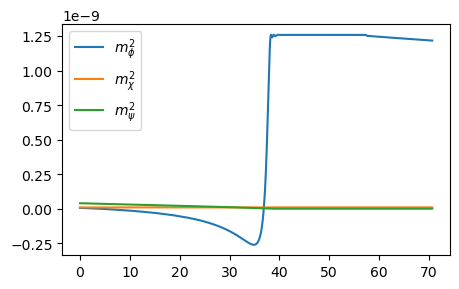

In [52]:
plt.figure(figsize=(5,3))
plt.plot(N_vals,MeffPhi,label=r'$m^2_\phi$')
plt.plot(N_vals,MeffChi,label=r'$m^2_\chi$')
plt.plot(N_vals,MeffPsi,label=r'$m^2_\psi$')
plt.legend()
plt.show()

The equation of state:

In [70]:
def EoS(Ne):
    idx = np.argmin(np.abs(Ne - N_vals))
    phi , chi , psi = phi_vals[idx] , chi_vals[idx] , psi_vals[idx]
    pot = V(phi,chi,psi)
    kin = sigma_dot(Ne)
    rho = 0.5 * power(kin,2) + pot
    prs = 0.5 * power(kin,2) - pot
    w = prs / rho
    return w

EOS = [EoS(n) for n in N_vals]

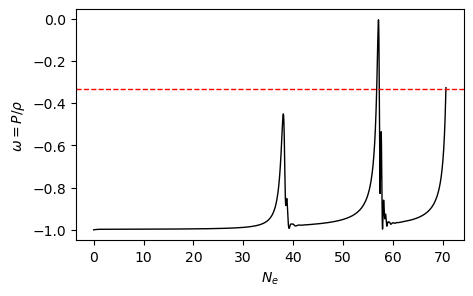

In [81]:
plt.figure(figsize=(5,3))
plt.plot(N_vals,EOS,color='black',linewidth=1)
plt.axhline(-1/3,linewidth=1,linestyle='--',color='r')
plt.xlabel(r'$N_e$')
plt.ylabel(r'$\omega=P/\rho$')
plt.show()

Isocurvatures mass:

In [31]:
def Meff1(Ne):
    idx = np.argmin(np.abs(Ne - N_vals))
    phi , chi , psi , Hub = phi_vals[idx] , chi_vals[idx] , psi_vals[idx] , Hubble_vals[idx]
    Riem1212 = -np.exp(2 * b(phi)) * (b_phi(phi) ** 2 + b_phiphi(phi))
    Riem1313 = -np.exp(2 * y(phi) + 2 * p(chi)) * (y_phi(phi) ** 2 + y_phiphi(phi))
    Riem2323 = np.exp(2 * y(phi) + 2 * p(chi)) * p_chi(chi) * (b_phi(phi) - y_phi(phi))
    Riem1323 = -np.exp(2 * y(phi) + 2 * p(chi)) * (np.exp(2 * b(phi)) * b_phi(phi) * y_phi(phi) + p_chi(chi) ** 2 + p_chichi(chi))
    R_TNTN = Riem1212 * power(T1[idx] * N2[idx] - T2[idx] * N1[idx],2) + Riem1313 * power(T1[idx] * N3[idx] - T3[idx] * N1[idx],2) + Riem2323 * power(T2[idx] * N3[idx] - T3[idx] * N2[idx],2) + 2 * Riem1323 * (T1[idx] * N3[idx] - T3[idx] * N1[idx]) * (T2[idx] * N3[idx] - T3[idx] * N2[idx])
    V_term = V_phiphi(phi,chi,psi) * N1[idx] * N1[idx] + V_chichi(phi,chi,psi) * N2[idx] * N2[idx] + V_psipsi(phi,chi,psi) * N3[idx] * N3[idx] + 2 * V_phichi(phi,chi,psi) * N1[idx] * N2[idx] + 2 * V_phipsi(phi,chi,psi) * N1[idx] * N3[idx] + 2 * V_chipsi(phi,chi,psi) * N2[idx] * N3[idx]
    return V_term - OMEGA[idx] ** 2 - TORSION[idx] ** 2 - 2 * epsilon[idx] * power(Hub,2) * R_TNTN

In [32]:
def Meff2(Ne):
    idx = np.argmin(np.abs(Ne - N_vals))
    phi , chi , psi , Hub = phi_vals[idx] , chi_vals[idx] , psi_vals[idx] , Hubble_vals[idx]
    Riem1212 = -np.exp(2 * b(phi)) * (b_phi(phi) ** 2 + b_phiphi(phi))
    Riem1313 = -np.exp(2 * y(phi) + 2 * p(chi)) * (y_phi(phi) ** 2 + y_phiphi(phi))
    Riem2323 = np.exp(2 * y(phi) + 2 * p(chi)) * p_chi(chi) * (b_phi(phi) - y_phi(phi))
    Riem1323 = -np.exp(2 * y(phi) + 2 * p(chi)) * (np.exp(2 * b(phi)) * b_phi(phi) * y_phi(phi) + p_chi(chi) ** 2 + p_chichi(chi))
    R_TBTB = Riem1212 * power(T1[idx] * B2[idx] - T2[idx] * B1[idx],2) + Riem1313 * power(T1[idx] * B3[idx] - T3[idx] * B1[idx],2) + Riem2323 * power(T2[idx] * B3[idx] - T3[idx] * B2[idx],2) + 2 * Riem1323 * (T1[idx] * B3[idx] - T3[idx] * B1[idx]) * (T2[idx] * B3[idx] - T3[idx] * B2[idx])
    V_term = V_phiphi(phi,chi,psi) * B1[idx] * B1[idx] + V_chichi(phi,chi,psi) * B2[idx] * B2[idx] + V_psipsi(phi,chi,psi) * B3[idx] * B3[idx] + 2 * V_phichi(phi,chi,psi) * B1[idx] * B2[idx] + 2 * V_phipsi(phi,chi,psi) * B1[idx] * B3[idx] + 2 * V_chipsi(phi,chi,psi) * B2[idx] * B3[idx]
    return V_term - TORSION[idx] ** 2 - 2 * epsilon[idx] * power(Hub,2) * R_TBTB

In [33]:
MEff1 = [Meff1(x) for x in N_vals]
MEff2 = [Meff2(x) for x in N_vals]

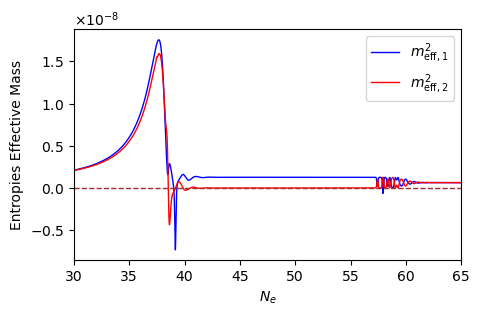

In [38]:
plt.figure(figsize=(5,3))
plt.plot(N_vals,MEff1,linewidth=1,color='b',label=r'$m^2_{\mathrm{eff},1}$')
plt.plot(N_vals,MEff2,linewidth=1,color='r',label=r'$m^2_{\mathrm{eff},2}$')
plt.axhline(0,linestyle='--',linewidth=1,color='brown')
plt.xlabel(r'$N_e$')
plt.ylabel('Entropies Effective Mass')
plt.xlim(30,65)
plt.legend()
formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((-2, 2)) 
plt.gca().yaxis.set_major_formatter(formatter)
plt.show()

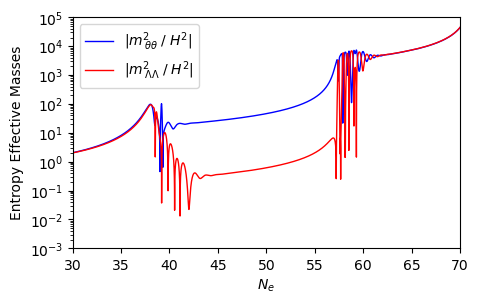

In [102]:
plt.figure(figsize=(5,3))
plt.semilogy(N_vals,np.abs(MEff1) / np.array(Hubble_vals) ** 2,linewidth=1,color='b',label=r'$|m^2_{\;\theta\theta}\;/\;H^2|$')
plt.semilogy(N_vals,np.abs(MEff2) / np.array(Hubble_vals) ** 2,linewidth=1,color='r',label=r'$|m^2_{\;\Lambda\Lambda}\;/\;H^2|$')
plt.axhline(0,linestyle='--',linewidth=1,color='brown')
plt.xlabel(r'$N_e$')
plt.ylabel('Entropy Effective Masses')
plt.xlim(30,70)
plt.ylim(1e-3,1e5)
plt.legend()
plt.show()

<center>
  <span style="color: #ff5722; font-weight: bold; font-size: 1.2em;">
    Perturbation 
  </span>
</center>

In [16]:
deltaN = 3    # this value is numerically stable in 3-field system

def N_subhorizon(k):
    exit_idx = np.argmin(np.abs(k - K))
    N_init = N_vals[exit_idx] - deltaN
    N_init_idx = np.argmin(np.abs(N_init - N_vals))
    if N_init_idx >= len(N_vals) - 1:
        return np.nan
    else:
        return N_vals[N_init_idx]

In [17]:
def BD_Inc1(k):
    N_init = N_subhorizon(k)
    idx = np.argmin(np.abs(N_vals - N_init))
    a , Hub = a_vals[idx] , Hubble_vals[idx]
    aH , eps , phi , chi, psi , phi_p , chi_p, psi_p = K[idx] , epsilon[idx] , phi_vals[idx] , chi_vals[idx], psi_vals[idx] , dphidN[idx] , dchidN[idx], dpsidN[idx]
    G = G_ab(phi,chi)
    BD_state = 1 / (a * np.sqrt(2 * k))
    dBD_dtau = -BD_state * (1j * k + aH)
    dBD_dN = dBD_dtau / aH
    inc1 = BD_state
    dinc1 = dBD_dN
    inc2 , dinc2 = 0 , 0
    inc3 , dinc3 = 0 , 0
    Phi = (phi_p * dinc1 + G[1][1] * chi_p * dinc2 + G[2][2] * psi_p * dinc3 + (3 * phi_p + b_phi(phi) * G[1][1] * chi_p ** 2 + y_phi(phi) * G[2][2] * psi_p ** 2 + V_phi(phi,chi,psi) / Hub ** 2) * inc1 + (3 * G[1][1] * chi_p + p_chi(chi) * G[2][2] * psi_p ** 2 + V_chi(phi,chi,psi) / Hub ** 2) * inc2 + (3 * G[2][2] * psi_p + V_psi(phi,chi,psi) / Hub ** 2) * inc3) / (2 * power(Mp,2) *(eps - k ** 2 / aH ** 2))
    Phi_p = - Phi + (phi_p * inc1 + G[1][1] * chi_p * inc2 + G[2][2] * psi_p * inc3) / (2 * power(Mp,2))
    return [inc1 , inc2 , inc3 , dinc1 , dinc2 , dinc3 , Phi , Phi_p]

def BD_Inc2(k):
    N_init = N_subhorizon(k)
    idx = np.argmin(np.abs(N_vals - N_init))
    a , Hub = a_vals[idx] , Hubble_vals[idx]
    aH , eps , phi , chi, psi , phi_p , chi_p, psi_p = K[idx] , epsilon[idx] , phi_vals[idx] , chi_vals[idx], psi_vals[idx] , dphidN[idx] , dchidN[idx], dpsidN[idx]
    G = G_ab(phi,chi)
    BD_state = 1 / (a * np.sqrt(2 * k))
    dBD_dtau = -BD_state * (1j * k + aH)
    dBD_dN = dBD_dtau / aH
    inc1 , dinc1 = 0 , 0
    inc2 = BD_state / np.sqrt(G[1][1])
    dinc2 = (dBD_dtau - b_phi(phi) * phi_p * BD_state * aH) / (aH * np.sqrt(G[1][1]))
    inc3 , dinc3 = 0 , 0
    Phi = (phi_p * dinc1 + G[1][1] * chi_p * dinc2 + G[2][2] * psi_p * dinc3 + (3 * phi_p + b_phi(phi) * G[1][1] * chi_p ** 2 + y_phi(phi) * G[2][2] * psi_p ** 2 + V_phi(phi,chi,psi) / Hub ** 2) * inc1 + (3 * G[1][1] * chi_p + p_chi(chi) * G[2][2] * psi_p ** 2 + V_chi(phi,chi,psi) / Hub ** 2) * inc2 + (3 * G[2][2] * psi_p + V_psi(phi,chi,psi) / Hub ** 2) * inc3) / (2 * power(Mp,2) *(eps - k ** 2 / aH ** 2))
    Phi_p = - Phi + (phi_p * inc1 + G[1][1] * chi_p * inc2 + G[2][2] * psi_p * inc3) / (2 * power(Mp,2))
    return [inc1 , inc2 , inc3 , dinc1 , dinc2 , dinc3 , Phi , Phi_p]

def BD_Inc3(k):
    N_init = N_subhorizon(k)
    idx = np.argmin(np.abs(N_vals - N_init))
    a , Hub = a_vals[idx] , Hubble_vals[idx]
    aH , eps , phi , chi, psi , phi_p , chi_p, psi_p = K[idx] , epsilon[idx] , phi_vals[idx] , chi_vals[idx], psi_vals[idx] , dphidN[idx] , dchidN[idx], dpsidN[idx]
    G = G_ab(phi,chi)
    BD_state = 1 / (a * np.sqrt(2 * k))
    dBD_dtau = -BD_state * (1j * k + aH)
    dBD_dN = dBD_dtau / aH
    inc1 , dinc1 = 0 , 0
    inc2 , dinc2 = 0 , 0
    inc3 = BD_state / np.sqrt(G[2][2])
    dinc3 = (dBD_dtau - BD_state * aH * (y_phi(phi) * phi_p + p_chi(chi) * chi_p)) / (aH * np.sqrt(G[2][2]))
    Phi = (phi_p * dinc1 + G[1][1] * chi_p * dinc2 + G[2][2] * psi_p * dinc3 + (3 * phi_p + b_phi(phi) * G[1][1] * chi_p ** 2 + y_phi(phi) * G[2][2] * psi_p ** 2 + V_phi(phi,chi,psi) / Hub ** 2) * inc1 + (3 * G[1][1] * chi_p + p_chi(chi) * G[2][2] * psi_p ** 2 + V_chi(phi,chi,psi) / Hub ** 2) * inc2 + (3 * G[2][2] * psi_p + V_psi(phi,chi,psi) / Hub ** 2) * inc3) / (2 * power(Mp,2) *(eps - k ** 2 / aH ** 2))
    Phi_p = - Phi + (phi_p * inc1 + G[1][1] * chi_p * inc2 + G[2][2] * psi_p * inc3) / (2 * power(Mp,2))
    return [inc1 , inc2 , inc3 , dinc1 , dinc2 , dinc3 , Phi , Phi_p]

In [18]:
# Mukhanov-Sasaki equations:

def Mukhanov_Sasaki(N,state,k):
    X1 , X2 , X3 , dX1_dN , dX2_dN , dX3_dN , Phi , dPhi = state 
    n = np.argmin(np.abs(N - N_vals))
    a , Hub , eps = a_vals[n] , Hubble_vals[n] , epsilon[n]
    aH = a * Hub
    phi , chi , psi , dphi , dchi , dpsi = phi_vals[n] , chi_vals[n] , psi_vals[n] , dphidN[n] , dchidN[n] , dpsidN[n]
    G = G_ab(phi,chi)
    d2X1dN2 = 4 * dPhi * dphi - 2 * Phi * V_phi(phi,chi,psi) / power(Hub,2) - (3 - eps) * dX1_dN - (power(k / aH,2) + V_phiphi(phi,chi,psi) / power(Hub,2) - (2 * b_phi(phi) ** 2 + b_phiphi(phi)) * G[1][1] * power(dchi,2) - (2 * y_phi(phi) ** 2 + y_phiphi(phi)) * G[2][2] * power(dpsi,2)) * X1 - (V_phichi(phi,chi,psi) / Hub ** 2 - 2 * y_phi(phi) * p_chi(chi) * G[2][2] * dpsi ** 2) * X2 + 2 * b_phi(phi) * G[1][1] * dchi * dX2_dN - V_phipsi(phi,chi,psi) * X3 / Hub ** 2 + 2 * y_phi(phi) * G[2][2] * dpsi * dX3_dN
    d2X2dN2 = 4 * dPhi * dchi - 2 * Phi * V_chi(phi,chi,psi) / (power(Hub,2) * G[1][1]) - (3 + 2 * b_phi(phi) * dphi - eps) * dX2_dN - (power(k / aH,2) + V_chichi(phi,chi,psi) / (power(Hub,2) * G[1][1]) - (2 * p_chi(chi) ** 2 + p_chichi(chi)) * G[2][2] * dpsi ** 2 / G[1][1]) * X2 - (2 * b_phiphi(phi) * dphi * dchi + V_phichi(phi,chi,psi) / (power(Hub,2) * G[1][1]) - 2 * b_phi(phi) * V_chi(phi,chi,psi) / (power(Hub,2) * G[1][1]) + 2 * (b_phi(phi) - y_phi(phi)) * p_chi(chi) * dpsi ** 2 * G[2][2] / G[1][1]) * X1 - 2 * b_phi(phi) * dchi * dX1_dN + 2 * p_chi(chi) * (G[2][2] / G[1][1]) * dpsi * dX3_dN - V_chipsi(phi,chi,psi) * X3 / (power(Hub,2) * G[1][1])
    d2X3dN2 = 4 * dPhi * dpsi - 2 * Phi * V_psi(phi,chi,psi) / (power(Hub,2) * G[2][2]) - (3 + 2 * y_phi(phi) * dphi + 2 * p_chi(chi) * dchi - eps) * dX3_dN - (power(k / aH,2) + V_psipsi(phi,chi,psi) / (power(Hub,2) * G[2][2])) * X3 - (2 * y_phiphi(phi) * dphi * dpsi - 2 * y_phi(phi) * V_psi(phi,chi,psi) / (power(Hub,2) * G[2][2]) + V_phipsi(phi,chi,psi) / (power(Hub,2) * G[2][2])) * X1 - (2 * p_chichi(chi) * dchi * dpsi - 2 * p_chi(chi) * V_psi(phi,chi,psi) / (power(Hub,2) * G[2][2]) + V_chipsi(phi,chi,psi) / (power(Hub,2) * G[2][2])) * X2 - 2 * y_phi(phi) * dpsi * dX1_dN - 2 * p_chi(chi) * dpsi * dX2_dN
    d2PhidN2 = -(7 - eps) * dPhi - (2 * V(phi,chi,psi) / power(Mp * Hub,2) + power(k / aH,2)) * Phi - (V_phi(phi,chi,psi) * X1 + V_chi(phi,chi,psi) * X2 + V_psi(phi,chi,psi) * X3) / power(Hub * Mp,2)
    return np.array([dX1_dN , dX2_dN , dX3_dN , d2X1dN2 , d2X2dN2 , d2X3dN2 , dPhi , d2PhidN2])

In [19]:
def Runge_Kutta(k, init):
    A = init
    N_init = N_subhorizon(k)
    NEP = [x for x in N_vals if x >= N_init]
    solutions = np.zeros((len(NEP), len(A)), dtype = complex)
    dN = NEP[1] - NEP[0]
    for i, Ne in enumerate(NEP):
        solutions[i, :] = A     # this line must be checked! 
        k1 = Mukhanov_Sasaki(Ne, A, k)
        k2 = Mukhanov_Sasaki(Ne + 0.5 * dN, A + 0.5 * k1 * dN, k)
        k3 = Mukhanov_Sasaki(Ne + 0.5 * dN, A + 0.5 * k2 * dN, k)
        k4 = Mukhanov_Sasaki(Ne + dN, A + k3 * dN, k)
        A += (dN / 6) * (k1 + 2 * k2 + 2 * k3 + k4)
    return NEP , solutions[:, 0] , solutions[:,1] , solutions[:,2] , solutions[:,6] 

In [20]:
# power spectrum calculator

def CPS(k):
    T1 , Delta_phi1 , Delta_chi1 , Delta_psi1, Phi_B1 = Runge_Kutta(k,BD_Inc1(k))
    T2 , Delta_phi2 , Delta_chi2 , Delta_psi2, Phi_B2 = Runge_Kutta(k,BD_Inc2(k))
    T3 , Delta_phi3 , Delta_chi3 , Delta_psi3, Phi_B3 = Runge_Kutta(k,BD_Inc3(k))
    #end_idx = np.argmin(np.abs(1 - epsilon))
    end_idx = end_inf
    sol_idx = np.argmin(np.abs(N_vals[end_idx] - T1))
    Hub = Hubble_vals[end_idx]
    sigma = sigma_vals[end_idx]
    phi , chi , psi , dphi , dchi , dpsi = phi_vals[end_idx] , chi_vals[end_idx] , psi_vals[end_idx] , dphidN[end_idx] , dchidN[end_idx] , dpsidN[end_idx]
    G = G_ab(phi,chi)
    R1 = Phi_B1[sol_idx] + power(Hub / sigma,2) * (dphi * Delta_phi1[sol_idx] + G[1][1] * dchi * Delta_chi1[sol_idx] + G[2][2] * dpsi * Delta_psi1[sol_idx])
    R2 = Phi_B2[sol_idx] + power(Hub / sigma,2) * (dphi * Delta_phi2[sol_idx] + G[1][1] * dchi * Delta_chi2[sol_idx] + G[2][2] * dpsi * Delta_psi2[sol_idx])
    R3 = Phi_B3[sol_idx] + power(Hub / sigma,2) * (dphi * Delta_phi3[sol_idx] + G[1][1] * dchi * Delta_chi3[sol_idx] + G[2][2] * dpsi * Delta_psi3[sol_idx])
    Sol = np.abs(R1) ** 2 + np.abs(R2) ** 2 + np.abs(R3) ** 2 
    return (k ** 3 / (2 * power(np.pi,2))) * Sol

In [21]:
c_idx = np.argmin(np.abs(0.05 * mpc - K))
K[c_idx] / mpc

np.float64(0.05000000000000001)

In [23]:
CPS(K[c_idx])

np.float64(2.1005615277302404e-09)

In [32]:
n_elements = len(K) 
indices = np.linspace(np.argmin(np.abs(17 - N_vals)), n_elements - 1, 300, dtype = int)
k_sample = [K[i] for i in indices]
N_sample = [N_vals[i] for i in indices]

POW = np.array([CPS(k) for k in k_sample])

In [ ]:
highlight_N = N_vals[c_idx]
highlight_POW = CPS(K[c_idx])

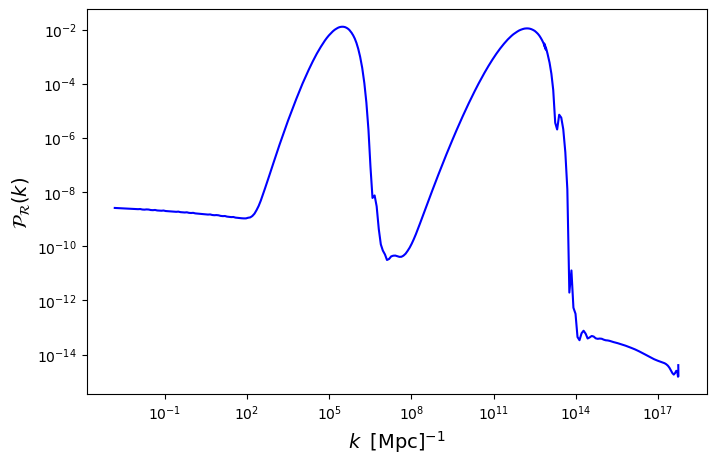

In [ ]:
plt.figure(figsize=(8, 5))
plt.loglog(np.array(k_sample) / mpc,POW, color ='b')
plt.xlabel(r'$k\;\;[\mathrm{Mpc}]^{-1}$',fontweight='bold', fontsize=14)
plt.ylabel(r'$\mathcal{P}_\mathcal{R}(k)$',fontweight='bold', fontsize=14)
#plt.savefig('3F_power_inK.pdf',format = 'pdf' ,  bbox_inches="tight", dpi = 600)
plt.show()

In [ ]:
import pandas as pd

df = pd.DataFrame({"N": N_sample, "K": k_sample, "P_R": POW})
df.to_csv("3F_F.csv", index=False)

In [83]:
import pandas as pd
df1 = pd.read_csv('3F_H.csv')

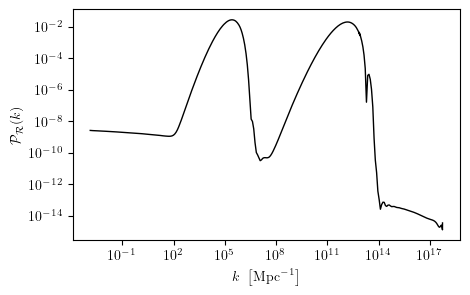

In [100]:
plt.figure(figsize=(5, 3))
plt.loglog(df1['K']/ mpc, df1['P_R'],color='black',linewidth=1)
plt.rcParams['text.usetex'] = True
plt.xlabel(r'$k\;\;\big[\mathrm{Mpc}^{-1}\big]$',fontweight='bold')
plt.ylabel(r'$\mathcal{P}_\mathcal{R}(k)$',fontweight='bold')
#plt.savefig('3F_power_2peaks.pdf',format = 'pdf' ,  bbox_inches="tight", dpi = 600)
plt.show()

Tracking perturbations:

In [38]:
def EntropyTracker(k):
    Tspan1 , Q_phi1 , Q_chi1 , Q_psi1, Phi_B1 = Runge_Kutta(k,BD_Inc1(k))
    Tspan2 , Q_phi2 , Q_chi2 , Q_psi2, Phi_B2 = Runge_Kutta(k,BD_Inc2(k))
    Tspan3 , Q_phi3 , Q_chi3 , Q_psi3, Phi_B3 = Runge_Kutta(k,BD_Inc3(k))
    Q_norm11 , Q_norm12 , Q_norm13 = [] , [] , []
    Q_norm21 , Q_norm22 , Q_norm23 = [] , [] , []
    for i,ne in enumerate(Tspan1):
        idx = np.argmin(np.abs(ne - N_vals))
        Hub = Hubble_vals[idx]
        sigma = sigma_vals[idx]
        phi , chi , psi , dphi , dchi , dpsi = phi_vals[idx] , chi_vals[idx] , psi_vals[idx] , dphidN[idx] , dchidN[idx] , dpsidN[idx]
        G = G_ab(phi,chi)
        Phi1 , Phi2 , Phi3 = Phi_B1[i] , Phi_B2[i] , Phi_B3[i]
        MSQ1_1 , MSQ1_2 , MSQ1_3 = Q_phi1[i] + dphidN[idx] * Phi1 , Q_phi2[i] + dphidN[idx] * Phi2 , Q_phi3[i] + dphidN[idx] * Phi3
        MSQ2_1 , MSQ2_2 , MSQ2_3 = Q_chi1[i] + dchidN[idx] * Phi1 , Q_chi2[i] + dchidN[idx] * Phi2 , Q_chi3[i] + dchidN[idx] * Phi3
        MSQ3_1 , MSQ3_2 , MSQ3_3 = Q_psi1[i] + dpsidN[idx] * Phi1 , Q_psi2[i] + dpsidN[idx] * Phi2 , Q_psi3[i] + dpsidN[idx] * Phi3
        Q1_s1 = N1[idx] * MSQ1_1 + G[1][1] * N2[idx] * MSQ2_1 + G[2][2] * N3[idx] * MSQ3_1
        Q2_s1 = N1[idx] * MSQ1_2 + G[1][1] * N2[idx] * MSQ2_2 + G[2][2] * N3[idx] * MSQ3_2
        Q3_s1 = N1[idx] * MSQ1_3 + G[1][1] * N2[idx] * MSQ2_3 + G[2][2] * N3[idx] * MSQ3_3
        Q1_s2 = B1[idx] * MSQ1_1 + G[1][1] * B2[idx] * MSQ2_1 + G[2][2] * B3[idx] * MSQ3_1
        Q2_s2 = B1[idx] * MSQ1_2 + G[1][1] * B2[idx] * MSQ2_2 + G[2][2] * B3[idx] * MSQ3_2
        Q3_s2 = B1[idx] * MSQ1_3 + G[1][1] * B2[idx] * MSQ2_3 + G[2][2] * B3[idx] * MSQ3_3
        Q_norm11.append(Q1_s1 * Hub / sigma)
        Q_norm12.append(Q2_s1 * Hub / sigma)
        Q_norm13.append(Q3_s1 * Hub / sigma)
        Q_norm21.append(Q1_s2 * Hub / sigma)
        Q_norm22.append(Q2_s2 * Hub / sigma)
        Q_norm23.append(Q3_s2 * Hub / sigma)
    Q_norm11 , Q_norm12 , Q_norm13 = np.array(Q_norm11) , np.array(Q_norm12) , np.array(Q_norm13)
    Q_norm21 , Q_norm22 , Q_norm23 = np.array(Q_norm21) , np.array(Q_norm22) , np.array(Q_norm23) 
    iso1 = np.abs(Q_norm11) ** 2 + np.abs(Q_norm12) ** 2 + np.abs(Q_norm13) ** 2
    iso2 = np.abs(Q_norm21) ** 2 + np.abs(Q_norm22) ** 2 + np.abs(Q_norm23) ** 2
    pow2 = (k ** 3 / (2 * np.pi ** 2)) * iso1
    pow3 = (k ** 3 / (2 * np.pi ** 2)) * iso2
    return Tspan1 , pow2 , pow3

In [39]:
def AdiabaticTracker(k):
    Tspan1 , Q_phi1 , Q_chi1 , Q_psi1, Phi_B1 = Runge_Kutta(k,BD_Inc1(k))
    Tspan2 , Q_phi2 , Q_chi2 , Q_psi2, Phi_B2 = Runge_Kutta(k,BD_Inc2(k))
    Tspan3 , Q_phi3 , Q_chi3 , Q_psi3, Phi_B3 = Runge_Kutta(k,BD_Inc3(k))
    Q_norm1 , Q_norm2 , Q_norm3 = [] , [] , []
    for i,ne in enumerate(Tspan1):
        idx = np.argmin(np.abs(ne - N_vals))
        Hub = Hubble_vals[idx]
        sigma = sigma_vals[idx]
        phi , chi , psi , dphi , dchi , dpsi = phi_vals[idx] , chi_vals[idx] , psi_vals[idx] , dphidN[idx] , dchidN[idx] , dpsidN[idx]
        G = G_ab(phi,chi)
        Phi1 , Phi2 , Phi3 = Phi_B1[i] , Phi_B2[i] , Phi_B3[i]
        MSQ1_1 , MSQ1_2 , MSQ1_3 = Q_phi1[i] + dphidN[idx] * Phi1 , Q_phi2[i] + dphidN[idx] * Phi2 , Q_phi3[i] + dphidN[idx] * Phi3
        MSQ2_1 , MSQ2_2 , MSQ2_3 = Q_chi1[i] + dchidN[idx] * Phi1 , Q_chi2[i] + dchidN[idx] * Phi2 , Q_chi3[i] + dchidN[idx] * Phi3
        MSQ3_1 , MSQ3_2 , MSQ3_3 = Q_psi1[i] + dpsidN[idx] * Phi1 , Q_psi2[i] + dpsidN[idx] * Phi2 , Q_psi3[i] + dpsidN[idx] * Phi3
        Q1_sigma = T1[idx] * MSQ1_1 + G[1][1] * T2[idx] * MSQ2_1 + G[2][2] * T3[idx] * MSQ3_1
        Q2_sigma = T1[idx] * MSQ1_2 + G[1][1] * T2[idx] * MSQ2_2 + G[2][2] * T3[idx] * MSQ3_2
        Q3_sigma = T1[idx] * MSQ1_3 + G[1][1] * T2[idx] * MSQ2_3 + G[2][2] * T3[idx] * MSQ3_3
        Q_norm1.append(Q1_sigma * Hub / sigma)
        Q_norm2.append(Q2_sigma * Hub / sigma)
        Q_norm3.append(Q3_sigma * Hub / sigma)
    Q_norm1 , Q_norm2 , Q_norm3 = np.array(Q_norm1) , np.array(Q_norm2) , np.array(Q_norm3)
    curv = np.abs(Q_norm1) ** 2 + np.abs(Q_norm2) ** 2 + np.abs(Q_norm3) ** 2
    pow = (k ** 3 / (2 * np.pi ** 2)) * curv
    return Tspan1 , pow

Tracking CMB mode:

In [56]:
Ne , pow_iso1 , pow_iso2 = EntropyTracker(K[c_idx])

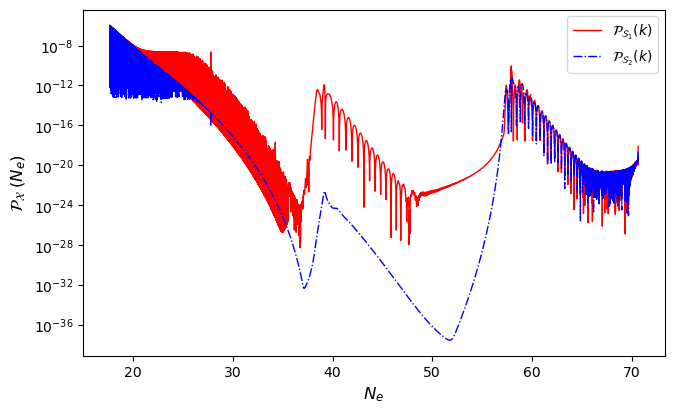

In [58]:
plt.figure(figsize=(7.5, 4.5))
plt.semilogy(Ne, pow_iso1,label = r'$\mathcal{P}_{\mathcal{S}_1}(k)$',color='r',linewidth=1)
plt.semilogy(Ne, pow_iso2,label = r'$\mathcal{P}_{\mathcal{S}_2}(k)$',color='b',linestyle='-.',linewidth=1)
plt.xlabel(r'$N_e$',fontsize=12)
plt.ylabel(r'$\mathcal{P}_\mathcal{X}\;(N_e)$',fontsize=12)
plt.legend()
#plt.xlim(20,70)
#plt.ylim(1e-23,1e-8)
plt.show()

In [59]:
pow_iso2[-1] / (2e-9 + pow_iso2[-1])

np.float64(1.2429050984680624e-10)

In [60]:
(pow_iso2[-1] + pow_iso1[-1]) / (2e-9 + pow_iso2[-1] + pow_iso1[-1])

np.float64(5.252138347762413e-10)

Tracking first peak:

In [69]:
k1 = 2.6496e+05 * mpc
NHC = N_vals[np.argmin(np.abs(k1 - K))]
Ne , pow_curv = AdiabaticTracker(k1)
Ne2 , pow_iso1 , pow_iso2 = EntropyTracker(k1)

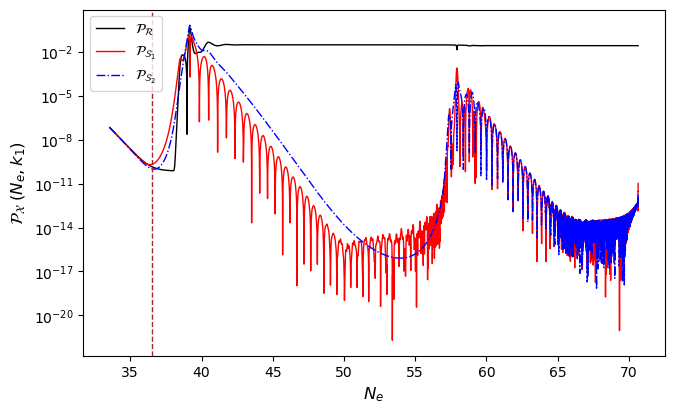

In [70]:
plt.figure(figsize=(7.5, 4.5))
plt.semilogy(Ne, pow_curv,label = r'$\mathcal{P}_{\mathcal{R}}$',color='black',linewidth=1)
plt.semilogy(Ne2, pow_iso1,label = r'$\mathcal{P}_{\mathcal{S}_1}$',color='r',linewidth=1)
plt.semilogy(Ne2, pow_iso2,label = r'$\mathcal{P}_{\mathcal{S}_2}$',color='b',linestyle='-.',linewidth=1)
plt.axvline(NHC,linestyle='--',linewidth=1,color='brown')
plt.xlabel(r'$N_e$',fontsize=12)
plt.ylabel(r'$\mathcal{P}_\mathcal{X}\;(N_e,k_1)$',fontsize=12)
plt.legend()
#plt.xlim(65,100)
#plt.ylim(1e-23,1e-8)
plt.show()

Tracking second peak:

In [64]:
k2 = 1.4831e+12 * mpc
NHC = N_vals[np.argmin(np.abs(k2 - K))]
Ne , pow_curv = AdiabaticTracker(k2)
Ne2 , pow_iso1 , pow_iso2 = EntropyTracker(k2)

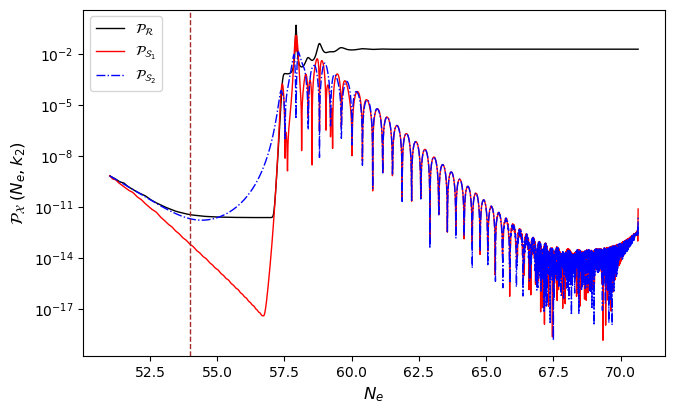

In [67]:
plt.figure(figsize=(7.5, 4.5))
plt.semilogy(Ne, pow_curv,label = r'$\mathcal{P}_{\mathcal{R}}$',color='black',linewidth=1)
plt.semilogy(Ne2, pow_iso1,label = r'$\mathcal{P}_{\mathcal{S}_1}$',color='r',linewidth=1)
plt.semilogy(Ne2, pow_iso2,label = r'$\mathcal{P}_{\mathcal{S}_2}$',color='b',linestyle='-.',linewidth=1)
plt.axvline(NHC,linestyle='--',linewidth=1,color='brown')
plt.xlabel(r'$N_e$',fontsize=12)
plt.ylabel(r'$\mathcal{P}_\mathcal{X}\;(N_e,k_2)$',fontsize=12)
plt.legend()
#plt.xlim(65,100)
#plt.ylim(1e-23,1e-8)
plt.show()

In [41]:
k1 = 2.6496e+05 * mpc
NHC1 = N_vals[np.argmin(np.abs(k1 - K))]
Ne1 , pow_curv1 = AdiabaticTracker(k1)
Ne_iso1 , pow_iso11 , pow_iso12 = EntropyTracker(k1)

k2 = 1.4831e+12 * mpc
NHC2 = N_vals[np.argmin(np.abs(k2 - K))]
Ne2 , pow_curv2 = AdiabaticTracker(k2)
Ne_iso2 , pow_iso21 , pow_iso22 = EntropyTracker(k2)

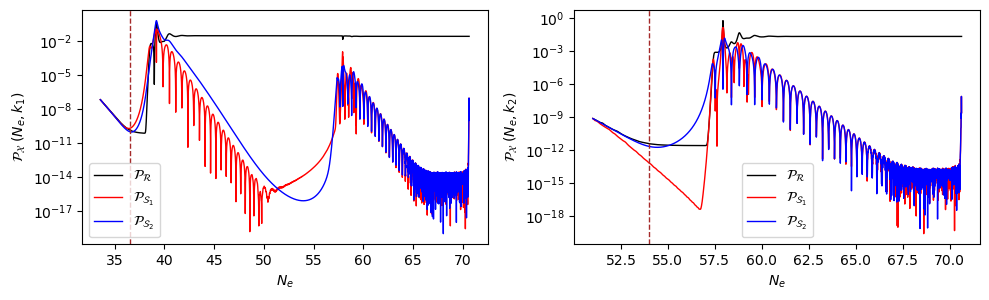

In [60]:
fig = plt.figure(figsize=(10, 3.1))

ax1 = fig.add_subplot(1,2,1)
ax1.semilogy(Ne1, pow_curv1,label = r'$\mathcal{P}_{\mathcal{R}}$',color='black',linewidth=1)
ax1.semilogy(Ne_iso1, pow_iso11,label = r'$\mathcal{P}_{\mathcal{S}_1}$',color='r',linewidth=1)
ax1.semilogy(Ne_iso1, pow_iso12,label = r'$\mathcal{P}_{\mathcal{S}_2}$',color='b',linewidth=1)
ax1.axvline(NHC1,linestyle='--',linewidth=1,color='brown')
ax1.set_xlabel(r'$N_e$')
ax1.set_ylabel(r'$\mathcal{P}_\mathcal{X}\;(N_e,k_1)$')
ax1.legend()

ax2 = fig.add_subplot(1,2,2)
ax2.semilogy(Ne2, pow_curv2,label = r'$\mathcal{P}_{\mathcal{R}}$',color='black',linewidth=1)
ax2.semilogy(Ne_iso2, pow_iso21,label = r'$\mathcal{P}_{\mathcal{S}_1}$',color='r',linewidth=1)
ax2.semilogy(Ne_iso2, pow_iso22,label = r'$\mathcal{P}_{\mathcal{S}_2}$',color='b',linewidth=1)
ax2.axvline(NHC2,linestyle='--',linewidth=1,color='brown')
ax2.set_xlabel(r'$N_e$')
ax2.set_ylabel(r'$\mathcal{P}_\mathcal{X}\;(N_e,k_2)$')
ax2.legend()

plt.tight_layout()
#plt.savefig('PerturbationTracking.pdf',format = 'pdf' , dpi = 700)
plt.show()
